In [26]:
# IMports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#To split x and y into train and test sets (x_train, x_test, y_train and y_test)
from sklearn.model_selection import train_test_split

#To bring the data(independent variables) into same scale
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score


In [27]:
#Import data
data = pd.read_csv("Attrition.csv")
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


#### EDA and Preprocessing

In [28]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender',
       'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [29]:
data.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
YearsWithCurrManager         int64
dtype: object

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [31]:
# Null values

data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [32]:
data.NumCompaniesWorked

0       1.0
1       0.0
2       1.0
3       3.0
4       4.0
       ... 
4405    3.0
4406    2.0
4407    0.0
4408    0.0
4409    0.0
Name: NumCompaniesWorked, Length: 4410, dtype: float64

In [33]:
data.TotalWorkingYears

0        1.0
1        6.0
2        5.0
3       13.0
4        9.0
        ... 
4405    10.0
4406    10.0
4407     5.0
4408    10.0
4409     NaN
Name: TotalWorkingYears, Length: 4410, dtype: float64

In [34]:
# See the data labels

for i in data.columns:
    print("*****************************************",i,"*****************************************")
    print()
    print(set(data[i].tolist()))
    print()

***************************************** Age *****************************************

{18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60}

***************************************** Attrition *****************************************

{'Yes', 'No'}

***************************************** BusinessTravel *****************************************

{'Travel_Frequently', 'Travel_Rarely', 'Non-Travel'}

***************************************** Department *****************************************

{'Sales', 'Research & Development', 'Human Resources'}

***************************************** DistanceFromHome *****************************************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29}

***************************************** Education *****************************************

{1, 2, 3, 4, 5}

In [35]:
# Imputing Null values

data['NumCompaniesWorked'].fillna(data['NumCompaniesWorked'].median(),inplace = True)
data['TotalWorkingYears'].fillna(data['TotalWorkingYears'].median(),inplace = True)

In [36]:
data.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [37]:
# Encoding Categorical Variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [38]:
# Encoding in one go

cat_cols = ['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus']

for col in cat_cols:
    
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [39]:
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,0,2,2,6,2,1,1,1,0,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,1,1,1,10,1,1,1,2,0,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,0,1,1,17,4,4,1,3,1,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,0,0,1,2,5,1,1,4,1,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,0,2,1,10,1,3,1,5,1,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [40]:
data.nunique()

Age                          43
Attrition                     2
BusinessTravel                3
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
EmployeeCount                 1
EmployeeID                 4410
Gender                        2
JobLevel                      5
JobRole                       9
MaritalStatus                 3
MonthlyIncome              1349
NumCompaniesWorked           10
Over18                        1
PercentSalaryHike            15
StandardHours                 1
StockOptionLevel              4
TotalWorkingYears            40
TrainingTimesLastYear         7
YearsAtCompany               37
YearsSinceLastPromotion      16
YearsWithCurrManager         18
dtype: int64

In [41]:
data['Age'].unique()

array([51, 31, 32, 38, 46, 28, 29, 25, 45, 36, 55, 47, 37, 21, 35, 26, 50,
       53, 42, 44, 49, 18, 41, 39, 58, 33, 43, 52, 27, 30, 54, 40, 23, 48,
       57, 34, 24, 22, 56, 60, 19, 20, 59])

In [42]:
# Drop columns - EmployeeCount,Over18,StandardHours,EmployeeID (these has only one category for all the rows)

data.drop('EmployeeCount', axis = 1, inplace = True)
data.drop('Over18', axis = 1, inplace = True)
data.drop('StandardHours', axis = 1, inplace = True)
data.drop('EmployeeID', axis = 1, inplace = True)



In [43]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'Gender', 'JobLevel', 'JobRole',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [44]:
# Assignment 1: Detect and treat outliers (using IQR and Z Score Method), also visualise using boxplot

# Assignment 2: Plot barchart and Piechart/donut chart for categorical variables

# Assignment 3: Plot Correlation Heatmap

# Assignment 4: Drop Duplicates (Deduplication or deduping)

#### Model Building and Prediction

In [45]:
# Split the data into independent and target variable

x = data.drop(['Attrition'], axis = 1)
y = data['Attrition']

In [46]:
x

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,2,2,6,2,1,0,1,0,1,131160,1.0,11,0,1.0,6,1,0,0
1,31,1,1,10,1,1,0,1,6,2,41890,0.0,23,1,6.0,3,5,1,4
2,32,1,1,17,4,4,1,4,7,1,193280,1.0,15,3,5.0,2,5,0,3
3,38,0,1,2,5,1,1,3,1,1,83210,3.0,11,3,13.0,5,8,7,5
4,32,2,1,10,1,3,1,1,7,2,23420,4.0,12,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,2,1,5,4,3,0,1,6,2,60290,3.0,17,1,10.0,5,3,0,2
4406,29,2,1,2,4,3,1,1,2,0,26790,2.0,15,0,10.0,2,3,0,2
4407,25,2,1,25,2,1,1,2,7,1,37020,0.0,20,0,5.0,4,4,1,2
4408,42,2,2,18,2,3,1,1,2,0,23980,0.0,14,1,10.0,2,9,7,8


In [47]:
y

0       0
1       1
2       0
3       0
4       0
       ..
4405    0
4406    0
4407    0
4408    0
4409    0
Name: Attrition, Length: 4410, dtype: int64

In [48]:
# Split the data into train and test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 12)

In [49]:
x_train

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
329,52,2,1,29,3,1,1,2,4,1,29420,8.0,11,1,9.0,1,5,1,4
2975,26,2,1,8,3,3,1,2,3,2,157870,1.0,12,2,8.0,5,8,7,4
4396,45,2,1,18,1,1,0,2,8,1,58110,0.0,14,0,25.0,4,24,1,7
3495,39,1,2,1,3,2,1,2,0,0,67550,7.0,14,1,21.0,2,18,11,5
2580,34,1,1,9,4,1,0,2,4,1,26250,1.0,12,3,16.0,4,15,6,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3916,47,0,1,3,2,1,0,2,7,1,39550,7.0,12,1,4.0,5,1,0,0
1283,29,2,1,28,4,1,0,1,8,1,48410,0.0,11,0,6.0,3,5,0,4
3714,39,0,1,2,4,3,1,2,4,2,43810,2.0,15,2,11.0,1,1,0,0
3325,42,2,1,18,1,5,0,2,6,1,199990,2.0,23,1,17.0,6,5,1,3


In [50]:
x_test

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
2944,32,2,1,10,1,3,1,1,7,2,23420,4.0,12,2,9.0,2,6,0,4
2905,38,2,1,1,2,3,1,4,2,0,64720,0.0,12,0,17.0,4,16,5,13
2152,39,2,1,18,2,1,1,2,2,2,28360,0.0,20,0,6.0,3,5,0,3
493,50,0,0,2,2,1,1,1,2,1,36880,0.0,11,0,19.0,3,18,0,13
2456,30,1,2,9,3,1,1,1,5,2,95820,0.0,12,1,10.0,2,9,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,45,0,1,8,1,1,1,2,7,1,33190,1.0,12,1,9.0,3,9,0,8
1030,35,0,2,10,1,1,0,2,5,0,43230,2.0,18,3,15.0,3,7,1,7
3201,29,1,2,2,4,1,1,4,0,0,64990,1.0,18,3,10.0,3,10,2,8
968,32,1,2,1,1,2,1,2,2,1,88580,6.0,16,1,10.0,2,5,1,3


In [51]:
y_train

329     0
2975    1
4396    0
3495    1
2580    0
       ..
3916    0
1283    0
3714    1
3325    0
1414    0
Name: Attrition, Length: 3528, dtype: int64

In [52]:
y_test

2944    0
2905    0
2152    1
493     0
2456    0
       ..
438     0
1030    0
3201    0
968     0
2278    0
Name: Attrition, Length: 882, dtype: int64

In [54]:
# Feature Scaling -  to scale/normalise the variables into same scale.
# why we do it after splitting into train and test - to avoid data leakage.

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [55]:
x_train_scaled

array([[ 1.66450607,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.37982643, -0.03291494],
       [-1.19545371,  0.59124673, -0.49675166, ...,  0.1582527 ,
         1.46340281, -0.03291494],
       [ 0.8945169 ,  0.59124673, -0.49675166, ...,  2.74904404,
        -0.37982643,  0.81264755],
       ...,
       [ 0.23452618, -2.4274486 , -0.49675166, ..., -0.97521851,
        -0.68703131, -1.1603316 ],
       [ 0.56452154,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.37982643, -0.31476911],
       [-0.31546609, -0.91810093, -0.49675166, ..., -0.32752067,
        -0.07262156, -1.1603316 ]])

In [56]:
x_test_scaled

array([[-0.53546299,  0.59124673, -0.49675166, ..., -0.16559622,
        -0.68703131, -0.03291494],
       [ 0.12452773,  0.59124673, -0.49675166, ...,  1.45364837,
         0.84899306,  2.50377254],
       [ 0.23452618,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.68703131, -0.31476911],
       ...,
       [-0.86545835, -0.91810093,  1.39583999, ...,  0.48210162,
        -0.07262156,  1.09450172],
       [-0.53546299, -0.91810093,  1.39583999, ..., -0.32752067,
        -0.37982643, -0.31476911],
       [-0.42546454,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.68703131, -0.59662327]])

In [57]:
# Model Training - without hyperparameter

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [61]:
#Predict training

y_train_pred = model.predict(x_train_scaled)

In [62]:
#Predict Test

y_test_pred = model.predict(x_test_scaled)

#### Model Evaluation

In [63]:
#Test Accuracy
test_accuracy = accuracy_score(y_test,y_test_pred)
test_accuracy

0.8605442176870748

In [65]:
#Train Accuracy
train_accuracy = accuracy_score(y_train,y_train_pred)
train_accuracy

0.8378684807256236

##### Test Evaluation

In [66]:
# COnfusion Matrix

cm = confusion_matrix(y_test, y_test_pred)
cm

array([[751,   5],
       [118,   8]])

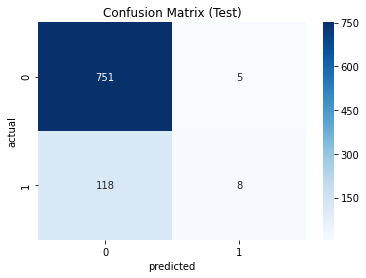

In [69]:
sns.heatmap(cm, fmt = 'd', annot = True, cmap = "Blues")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix (Test)")
plt.show()

In [71]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

In [72]:
tn

751

In [73]:
tp

8

In [74]:
fn

118

In [75]:
fp

5

In [76]:
# Recall

recall = tp/(tp+fn)
recall

0.06349206349206349

In [77]:
#Precision

precision = tp/(tp+fp)
precision

0.6153846153846154

In [80]:
# f1-score

f1_score = (2 * (precision * recall))/(precision + recall)

f1_score

0.11510791366906474

In [81]:
# ROC and (AUC of ROC Curve)
"""
predict_proba method returns the probabilities of each class for every instance in the dataset
e.g.: for a binary classfication, this method will return 2D array
        - column 0 will give will give probability of class 0
        - column 1 will give will give probability of class 1


"""

'\npredict_proba method returns the probabilities of each class for every instance in the dataset\ne.g.: for a binary classfication, this method will return 2D array\n        - column 0 will give will give probability of class 0\n        - column 1 will give will give probability of class 1\n\n\n'

In [85]:
y_test_prob = model.predict_proba(x_test_scaled)[:,1]
y_test_prob

array([0.29576427, 0.01530456, 0.20361498, 0.01473354, 0.11185642,
       0.2036986 , 0.20945036, 0.11959352, 0.31650676, 0.35939681,
       0.05304958, 0.02826607, 0.09600564, 0.11590951, 0.08504056,
       0.1855874 , 0.08837676, 0.04429863, 0.31359648, 0.31751009,
       0.29576427, 0.0301463 , 0.45379493, 0.35836787, 0.21024696,
       0.09402762, 0.14757648, 0.26496231, 0.09601216, 0.29606621,
       0.07902176, 0.12627207, 0.06321979, 0.30991578, 0.08523165,
       0.14949712, 0.19351997, 0.02715477, 0.07360861, 0.26357201,
       0.29431592, 0.04283084, 0.12584929, 0.06890379, 0.07143547,
       0.23807627, 0.4216728 , 0.39431942, 0.00975362, 0.08583104,
       0.07186484, 0.07344054, 0.16964855, 0.01178708, 0.03752715,
       0.27221314, 0.09108406, 0.07874304, 0.0675291 , 0.18185597,
       0.19458895, 0.45847645, 0.09553346, 0.11737727, 0.25446696,
       0.32111493, 0.19176154, 0.39890025, 0.09427987, 0.04245602,
       0.42043943, 0.27967674, 0.07378116, 0.29606621, 0.15194

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

In [87]:
fpr

array([0.        , 0.00132275, 0.00132275, 0.00132275, 0.00132275,
       0.00396825, 0.00396825, 0.00529101, 0.00529101, 0.00661376,
       0.00661376, 0.01190476, 0.01455026, 0.01455026, 0.01719577,
       0.01719577, 0.01984127, 0.01984127, 0.02116402, 0.02116402,
       0.02380952, 0.02513228, 0.02910053, 0.03042328, 0.03042328,
       0.03571429, 0.03571429, 0.03571429, 0.03835979, 0.03835979,
       0.03968254, 0.03968254, 0.04100529, 0.04100529, 0.04232804,
       0.04232804, 0.04497354, 0.05291005, 0.05555556, 0.06084656,
       0.06084656, 0.06084656, 0.06481481, 0.06481481, 0.06481481,
       0.06878307, 0.06878307, 0.07142857, 0.07142857, 0.07407407,
       0.07936508, 0.08333333, 0.08333333, 0.08597884, 0.08730159,
       0.08730159, 0.08994709, 0.08994709, 0.09126984, 0.09126984,
       0.09259259, 0.09259259, 0.09391534, 0.09391534, 0.09656085,
       0.09656085, 0.09920635, 0.09920635, 0.10449735, 0.10449735,
       0.11243386, 0.11640212, 0.11640212, 0.11772487, 0.12037

In [88]:
tpr

array([0.        , 0.        , 0.00793651, 0.02380952, 0.03968254,
       0.03968254, 0.05555556, 0.05555556, 0.06349206, 0.06349206,
       0.07142857, 0.07142857, 0.07142857, 0.08730159, 0.08730159,
       0.0952381 , 0.0952381 , 0.11111111, 0.11111111, 0.11904762,
       0.11904762, 0.11904762, 0.11904762, 0.11904762, 0.13492063,
       0.13492063, 0.15079365, 0.16666667, 0.16666667, 0.17460317,
       0.17460317, 0.18253968, 0.18253968, 0.19047619, 0.19047619,
       0.1984127 , 0.1984127 , 0.1984127 , 0.1984127 , 0.1984127 ,
       0.22222222, 0.23809524, 0.23809524, 0.24603175, 0.26190476,
       0.26190476, 0.27777778, 0.27777778, 0.29365079, 0.29365079,
       0.29365079, 0.29365079, 0.30952381, 0.30952381, 0.30952381,
       0.31746032, 0.31746032, 0.32539683, 0.32539683, 0.34126984,
       0.34126984, 0.34920635, 0.34920635, 0.36507937, 0.36507937,
       0.38095238, 0.38095238, 0.38888889, 0.38888889, 0.4047619 ,
       0.4047619 , 0.4047619 , 0.41269841, 0.41269841, 0.41269

In [91]:
auc = roc_auc_score(y_test, y_test_prob)
auc

0.7189888300999412

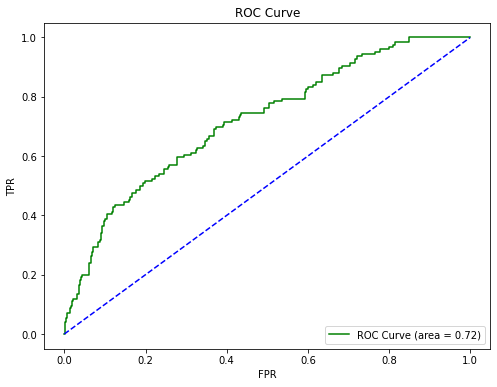

In [95]:
plt.figure(figsize= (8,6))
plt.plot(fpr, tpr, color = 'green', label=f'ROC Curve (area = {auc:.2f})')
plt.plot([0,1],[0,1], color = 'blue', linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()

In [96]:
"""
Hyperparameter:

1. Penalty- regularization parameter (to prevent overfitting)

    'l1': sum of absolute value of coefficients. Also called as Lasso.
    'l2': sum of squared value of coefficients. Also called as Ridge.
    'l1-l2 or elasticnet': combination of l1 and l2.
    
2. C - Regularization parameter

    (how stricter you want your model)
    
    high c value = less regularisation
    low c value = high regularisation
    
3. max_iter = max no. of iterations which model takes to converge (default = 100)

"""

"\nHyperparameter:\n\n1. Penalty- regularization parameter (to prevent overfitting)\n\n    'l1': sum of absolute value of coefficients. Also called as Lasso.\n    'l2': sum of squared value of coefficients. Also called as Ridge.\n    'l1-l2 or elasticnet': combination of l1 and l2.\n    \n2. C - Regularization parameter\n\n    (how stricter you want your model)\n    \n    high c value = less regularisation\n    low c value = high regularisation\n    \n3. max_iter = max no. of iterations which model takes to converge (default = 100)\n\n"

In [97]:
data.Attrition.value_counts()

0    3699
1     711
Name: Attrition, dtype: int64

#### Conclusion:

Model gave us the training accuracy of 84% and the test also gave us a good accuracy on the default hyperparameter. We have to tackle class imbalance problem as our target variable has majority of class 0 labels than class 1. Technique - SMOTE.